In [1]:
import torch
import matplotlib.pyplot as plt
import math

from renderer import project_gaussians, tile_gaussians,rasterize_tile
from utils import ellipse_ndim, plot_tile_map

from matplotlib.patches import Polygon
from tqdm import tqdm

### Data

In [2]:
N = 100

mu = (torch.rand((N,3)) - 0.5) * 4.
scale = torch.rand((N,3)) * 0.2
quat = torch.rand((N, 4))
col = torch.rand((N, 3))
opc = torch.rand((N,))

In [3]:
mu.requires_grad = True
scale.requires_grad = True
quat.requires_grad = True
col.requires_grad = True
opc.requires_grad = True

### Projection

In [4]:
# Output Image Width and Height
W = 1800
H = 1000 

In [5]:
fov_x = math.pi / 2.0 # Angle of the camera frustum 90°
focal = 0.5 * float(W) / math.tan(0.5 * fov_x) # Distance to Image Plane

viewmat = torch.eye(4)
viewmat[:3,3] = torch.tensor([0,0,-4])

In [6]:
(
    mu_,
    cov_,
    z
) = project_gaussians(
    means3d=mu,
    scales=scale,
    quats=quat,
    colors=col,
    viewmat=viewmat,
    fx=focal,
    fy=focal,
    cx=W/2,
    cy=H/2,
    img_height=H,
    img_width=W
)

### Rendering

In [7]:
tile_size = 200

In [8]:
tile_map = tile_gaussians(mu_, cov_, tile_size, H, W)

In [9]:
tile_map

[[[],
  [53, 67, 78, 99],
  [53, 63, 67, 70, 78, 80, 99],
  [49, 53, 63, 67, 70, 78, 80, 92, 93, 99],
  [8, 15, 17, 28, 32, 49, 63, 80, 92, 93, 94, 99],
  [8, 15, 17, 27, 28, 32, 48, 49, 58, 63, 64, 77, 80, 82, 92, 93, 94, 99],
  [8, 15, 17, 27, 32, 46, 48, 49, 58, 62, 64, 77, 82, 93, 94],
  [46, 48, 49, 58, 62, 77, 82],
  [77, 82]],
 [[95],
  [53, 55, 67, 75, 78, 95, 99],
  [30, 36, 53, 55, 60, 63, 67, 70, 72, 75, 78, 80, 95, 99],
  [19,
   30,
   36,
   43,
   49,
   51,
   53,
   54,
   55,
   60,
   63,
   67,
   70,
   72,
   75,
   78,
   80,
   88,
   92,
   93,
   95,
   99],
  [2,
   6,
   7,
   8,
   9,
   11,
   15,
   17,
   19,
   28,
   30,
   32,
   36,
   40,
   43,
   49,
   51,
   54,
   55,
   60,
   63,
   72,
   80,
   88,
   92,
   93,
   94,
   99],
  [2,
   6,
   7,
   8,
   9,
   11,
   15,
   17,
   20,
   23,
   26,
   27,
   28,
   32,
   38,
   40,
   41,
   43,
   47,
   48,
   49,
   51,
   56,
   58,
   60,
   63,
   64,
   77,
   80,
   82,
   88,
   92

In [10]:
out_img = torch.zeros(H, W, 3)
for y in tqdm(range(len(tile_map))):
    for x in range(len(tile_map[0])):
        if tile_map[y][x]:
            rasterize_tile(
                xys=mu_, covs=cov_, colors=col, opacity=opc,
                x_coord=x, y_coord=y, tile_size=tile_size,
                out_img=out_img,
                tile_map=tile_map
            )

  0%|          | 0/5 [00:00<?, ?it/s]

/home/yasin/anaconda3/lib/python3.11/site-packages/torch/functional.py:507: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3549.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
100%|██████████| 5/5 [00:05<00:00,  1.14s/it]


In [11]:
loss = out_img.mean()

In [12]:
loss.backward()

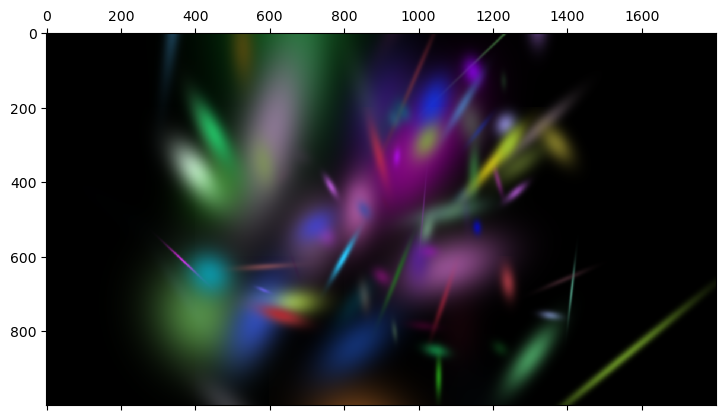

In [13]:
plt.matshow(out_img.detach())